# Term Project 1: VaR, CVaR, and Sector Stress Testing of a Mutual Fund Portfolio

## Objective
This notebook develops a risk analysis tool for a portfolio manager who invests \$1,000,000 equally across `d` mutual funds selected from a pool of equity mutual funds.

The notebook:
- constructs rolling $\tau$-horizon returns,
- forms an equal-weight portfolio,
- computes Value-at-Risk (VaR),
- computes Conditional Value-at-Risk (CVaR),
- and performs sector-based stress testing using fund sector exposure data.

The user can vary:
- start date `ts`
- end date `te`
- number of funds `d`
- rolling step $\delta$
- horizon $\tau$
- confidence level $\alpha$

## Imports

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_style("whitegrid")

## User-defined parameters

In [38]:
initial_capital = 1_000_000

d = 10
alpha = 0.95

ts = "2017-01-01"
te = "2024-12-31"

tau = 252      # 1 year in trading days
delta = 22     # monthly rolling

## Load and clean price data

In [39]:
DATA_DIR = Path("data")

raw_prices = pd.read_csv(DATA_DIR / "us_equity_adj_close.csv")
print("Raw equity price file shape:", raw_prices.shape)
display(raw_prices.head())

Raw equity price file shape: (9133, 76)


,as_of,B13779,B14678,B09156,B25037,B19389,B19569,B23689,B13231,B23166,...,B03952,B03459,B04369,B21505,B01637,B06905,B15668,B05924,B23372,B15619
0,1999-12-31,20.2885,NaN,18.9567,NaN,7827.79,NaN,17.5311,NaN,NaN,...,NaN,436.476,14.55,23.3542,NaN,62.0509,267.199,NaN,NaN,53.2148
1,2000-01-01,20.2885,NaN,18.9567,NaN,7827.79,NaN,17.5311,NaN,NaN,...,NaN,436.476,14.55,23.3542,NaN,62.0509,267.199,NaN,NaN,53.2148
2,2000-01-02,20.2885,NaN,18.9567,NaN,7827.79,NaN,17.5311,NaN,NaN,...,NaN,436.476,14.55,23.3542,NaN,62.0509,267.199,NaN,NaN,53.2148
3,2000-01-03,20.2885,NaN,18.3206,NaN,7704.46,NaN,17.2178,NaN,NaN,...,NaN,431.505,14.38,23.0128,NaN,60.8792,261.091,NaN,NaN,52.6983
4,2000-01-04,20.2885,NaN,17.9974,NaN,7418.31,NaN,16.7897,NaN,NaN,...,NaN,414.271,14.18,22.5703,NaN,59.1748,253.864,NaN,NaN,50.6881


In [42]:
raw_prices["as_of"] = pd.to_datetime(raw_prices["as_of"])
prices = raw_prices.set_index("as_of").sort_index()

print("Clean price matrix shape:", prices.shape)
display(prices.head())

Clean price matrix shape: (9133, 75)


,B13779,B14678,B09156,B25037,B19389,B19569,B23689,B13231,B23166,B06011,...,B03952,B03459,B04369,B21505,B01637,B06905,B15668,B05924,B23372,B15619
as_of,,,,,,,,,,,,,,,,,,,,,
1999-12-31,20.2885,NaN,18.9567,NaN,7827.79,NaN,17.5311,NaN,NaN,26.7517,...,NaN,436.476,14.55,23.3542,NaN,62.0509,267.199,NaN,NaN,53.2148
2000-01-01,20.2885,NaN,18.9567,NaN,7827.79,NaN,17.5311,NaN,NaN,26.7517,...,NaN,436.476,14.55,23.3542,NaN,62.0509,267.199,NaN,NaN,53.2148
2000-01-02,20.2885,NaN,18.9567,NaN,7827.79,NaN,17.5311,NaN,NaN,26.7517,...,NaN,436.476,14.55,23.3542,NaN,62.0509,267.199,NaN,NaN,53.2148
2000-01-03,20.2885,NaN,18.3206,NaN,7704.46,NaN,17.2178,NaN,NaN,26.3193,...,NaN,431.505,14.38,23.0128,NaN,60.8792,261.091,NaN,NaN,52.6983
2000-01-04,20.2885,NaN,17.9974,NaN,7418.31,NaN,16.7897,NaN,NaN,25.5627,...,NaN,414.271,14.18,22.5703,NaN,59.1748,253.864,NaN,NaN,50.6881


In [43]:
print("Top missing-value counts by fund:")
display(prices.isna().sum().sort_values(ascending=False).head(10))

Top missing-value counts by fund:


B10640    8261
B20889    8039
B00056    8031
B03952    7997
B18900    7698
B21794    7561
B12602    7211
B08620    7132
B18562    6287
B10090    6209
dtype: int64

## Load and clean sector exposure data

In [44]:
raw_sectors = pd.read_csv(DATA_DIR / "us_equity_sectors.csv")
print("Raw sector file shape:", raw_sectors.shape)
display(raw_sectors.head())

Raw sector file shape: (8492, 13)


,as_of,ask_id,equity_econ_sector_basic_materials_pct_net,equity_econ_sector_communication_services_pct_net,equity_econ_sector_consumer_cyclical_pct_net,equity_econ_sector_consumer_defensive_pct_net,equity_econ_sector_energy_pct_net,equity_econ_sector_financial_services_pct_net,equity_econ_sector_healthcare_pct_net,equity_econ_sector_industrials_pct_net,equity_econ_sector_real_est_pct_net,equity_econ_sector_technology_pct_net,equity_econ_sector_utilities_pct_net
0,2016-12,B00056,7.09,1.53,9.78,4.39,10.18,19.24,9.22,14.31,2.22,14.92,6.50
1,2017-01,B00056,7.69,1.12,10.34,3.97,9.18,19.31,8.79,14.83,2.39,16.33,5.60
2,2017-02,B00056,7.64,1.21,10.22,4.26,8.72,19.59,9.11,14.36,2.42,16.51,5.53
3,2017-03,B00056,8.01,1.21,10.32,3.96,7.76,18.25,9.42,14.28,2.38,18.17,5.16
4,2017-04,B00056,7.57,2.09,11.01,3.93,4.43,16.94,9.73,15.75,2.48,21.99,6.66


In [45]:
sectors_raw = raw_sectors.copy()
sectors_raw["as_of"] = pd.to_datetime(sectors_raw["as_of"])
sectors_raw = sectors_raw.rename(columns={"ask_id": "fund"})

In [46]:
sector_cols = [col for col in sectors_raw.columns if "_pct_net" in col]
print("Sector columns:")
print(sector_cols)

Sector columns:
['equity_econ_sector_basic_materials_pct_net', 'equity_econ_sector_communication_services_pct_net', 'equity_econ_sector_consumer_cyclical_pct_net', 'equity_econ_sector_consumer_defensive_pct_net', 'equity_econ_sector_energy_pct_net', 'equity_econ_sector_financial_services_pct_net', 'equity_econ_sector_healthcare_pct_net', 'equity_econ_sector_industrials_pct_net', 'equity_econ_sector_real_est_pct_net', 'equity_econ_sector_technology_pct_net', 'equity_econ_sector_utilities_pct_net']


In [47]:
ts_dt = pd.to_datetime(ts)

sectors_filtered = sectors_raw[sectors_raw["as_of"] <= ts_dt].copy()
sectors_filtered = sectors_filtered.sort_values(["fund", "as_of"])

sectors_latest = sectors_filtered.groupby("fund").tail(1)
print("Funds with sector data available by ts:", len(sectors_latest))
display(sectors_latest.head())

Funds with sector data available by ts: 67


,as_of,fund,equity_econ_sector_basic_materials_pct_net,equity_econ_sector_communication_services_pct_net,equity_econ_sector_consumer_cyclical_pct_net,equity_econ_sector_consumer_defensive_pct_net,equity_econ_sector_energy_pct_net,equity_econ_sector_financial_services_pct_net,equity_econ_sector_healthcare_pct_net,equity_econ_sector_industrials_pct_net,equity_econ_sector_real_est_pct_net,equity_econ_sector_technology_pct_net,equity_econ_sector_utilities_pct_net
1,2017-01-01,B00056,7.69,1.12,10.34,3.97,9.18,19.31,8.79,14.83,2.39,16.33,5.60
31,2017-01-01,B00496,2.28,1.88,18.89,5.99,1.18,7.10,17.25,11.98,1.32,28.63,0.00
95,2017-01-01,B00698,2.72,2.66,18.56,7.59,1.36,9.01,18.34,13.93,0.29,24.60,0.81
295,2017-01-01,B01060,1.66,2.36,6.82,25.81,9.51,14.95,11.77,3.56,0.00,22.80,0.00
489,2017-01-01,B01061,1.74,0.00,9.71,11.68,5.54,12.67,17.16,11.94,0.00,24.20,4.59


In [48]:
sectors_matrix = sectors_latest.set_index("fund")[sector_cols].copy()

In [49]:
def clean_sector_name(col):
    col = col.replace("equity_econ_sector_", "")
    col = col.replace("_pct_net", "")
    col = col.replace("_", " ")
    return col.title()

sectors_matrix.columns = [clean_sector_name(c) for c in sectors_matrix.columns]

In [50]:
sectors_matrix = sectors_matrix / 100
sectors_matrix = sectors_matrix.fillna(0)

print("Clean sector matrix shape:", sectors_matrix.shape)
display(sectors_matrix.head())

Clean sector matrix shape: (67, 11)


,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Real Est,Technology,Utilities
fund,,,,,,,,,,,
B00056,0.0769,0.0112,0.1034,0.0397,0.0918,0.1931,0.0879,0.1483,0.0239,0.1633,0.0560
B00496,0.0228,0.0188,0.1889,0.0599,0.0118,0.0710,0.1725,0.1198,0.0132,0.2863,0.0000
B00698,0.0272,0.0266,0.1856,0.0759,0.0136,0.0901,0.1834,0.1393,0.0029,0.2460,0.0081
B01060,0.0166,0.0236,0.0682,0.2581,0.0951,0.1495,0.1177,0.0356,0.0000,0.2280,0.0000
B01061,0.0174,0.0000,0.0971,0.1168,0.0554,0.1267,0.1716,0.1194,0.0000,0.2420,0.0459


## Align prices and sector data

In [51]:
common_funds = sorted(set(prices.columns).intersection(set(sectors_matrix.index)))

prices = prices[common_funds].copy()
sectors_matrix = sectors_matrix.loc[common_funds].copy()

print("Aligned prices shape:", prices.shape)
print("Aligned sectors shape:", sectors_matrix.shape)

Aligned prices shape: (9133, 67)
Aligned sectors shape: (67, 11)


In [52]:
print("Sector exposure row sums:")
display(sectors_matrix.sum(axis=1).head())

Sector exposure row sums:


fund
B00056    0.9955
B00496    0.9650
B00698    0.9987
B01060    0.9924
B01061    0.9923
dtype: float64

## Filter to the selected date range

In [53]:
prices_subset = prices.loc[ts:te].copy()

print("Filtered prices shape:", prices_subset.shape)
print("Date range:", prices_subset.index.min(), "to", prices_subset.index.max())

Filtered prices shape: (2922, 67)
Date range: 2017-01-01 00:00:00 to 2024-12-31 00:00:00


In [54]:
if len(prices_subset) <= tau:
    raise ValueError("Not enough observations in selected date range for chosen tau.")

## Select d funds

In [55]:
min_non_missing_ratio = 0.90
min_non_missing_count = int(min_non_missing_ratio * len(prices_subset))

available_funds = [
    col for col in prices_subset.columns
    if prices_subset[col].notna().sum() >= min_non_missing_count
]

print(f"Funds with at least {min_non_missing_ratio:.0%} coverage:", len(available_funds))

if len(available_funds) < d:
    raise ValueError(f"Only {len(available_funds)} funds meet the data requirement, but d={d}.")

Funds with at least 90% coverage: 60


In [56]:
selected_funds = available_funds[:d]

print("Selected funds:")
for f in selected_funds:
    print("-", f)

Selected funds:
- B00496
- B00698
- B01060
- B01061
- B01637
- B01855
- B02943
- B03459
- B03731
- B03784


In [57]:
prices_d = prices_subset[selected_funds].copy().dropna()
sectors_d = sectors_matrix.loc[selected_funds].copy()

print("Selected price matrix shape:", prices_d.shape)
print("Selected sector matrix shape:", sectors_d.shape)

Selected price matrix shape: (2922, 10)
Selected sector matrix shape: (10, 11)


In [58]:
if len(prices_d) <= tau:
    raise ValueError("Not enough observations after cleaning for chosen tau.")

## Methodology

For each fund `i`, the $\tau$-horizon return is defined as

$r^{(i)}_{t,\tau} = \frac{p^{(i)}_{t+\tau} - p^{(i)}_t}{p^{(i)}_t}$

To construct a usable historical distribution, returns are sampled using a rolling step `\delta`:
- daily: $\delta = 1$
- weekly: $\delta = 5$
- monthly: $\delta = 22$
- quarterly: $\delta = 66$

The portfolio is equally weighted across the selected `d` mutual funds:
$
w_i = \frac{1}{d}
$

VaR and CVaR are then computed from the empirical distribution of the portfolio's $\tau$-horizon returns.

## Construct rolling τ-horizon fund returns

In [59]:
def rolling_horizon_returns(prices, tau, delta):
    returns = []
    dates = []

    for i in range(0, len(prices) - tau + 1, delta):
        p_t = prices.iloc[i]
        p_t_tau = prices.iloc[i + tau - 1]
        r = (p_t_tau - p_t) / p_t
        returns.append(r)
        dates.append(prices.index[i])

    return pd.DataFrame(returns, index=dates)

In [60]:
fund_returns = rolling_horizon_returns(prices_d, tau=tau, delta=delta)

print("Fund return matrix shape:", fund_returns.shape)
display(fund_returns.head())

Fund return matrix shape: (122, 10)


,B00496,B00698,B01060,B01061,B01637,B01855,B02943,B03459,B03731,B03784
2017-01-01,0.151394,0.179725,0.151874,0.105685,0.105231,0.064583,0.127968,0.194911,0.254245,0.164442
2017-01-23,0.140167,0.162626,0.151070,0.113673,0.129960,0.100001,0.135266,0.185487,0.232749,0.162257
2017-02-14,0.127143,0.144891,0.136767,0.092311,0.112674,0.074110,0.114399,0.154311,0.211969,0.151115
2017-03-08,0.137977,0.147260,0.136173,0.070940,0.108358,0.083990,0.119374,0.163029,0.225825,0.150005
2017-03-30,0.150054,0.152119,0.143483,0.080083,0.126157,0.096076,0.127953,0.162776,0.224063,0.141303


## Construct equal-weight portfolio returns

In [61]:
weights = np.ones(d) / d
portfolio_returns = fund_returns @ weights

print("Number of portfolio return observations:", len(portfolio_returns))
display(portfolio_returns.head())

Number of portfolio return observations: 122


2017-01-01    0.150006
2017-01-23    0.151326
2017-02-14    0.131969
2017-03-08    0.134293
2017-03-30    0.140407
dtype: float64

## Visualize the portfolio return distribution

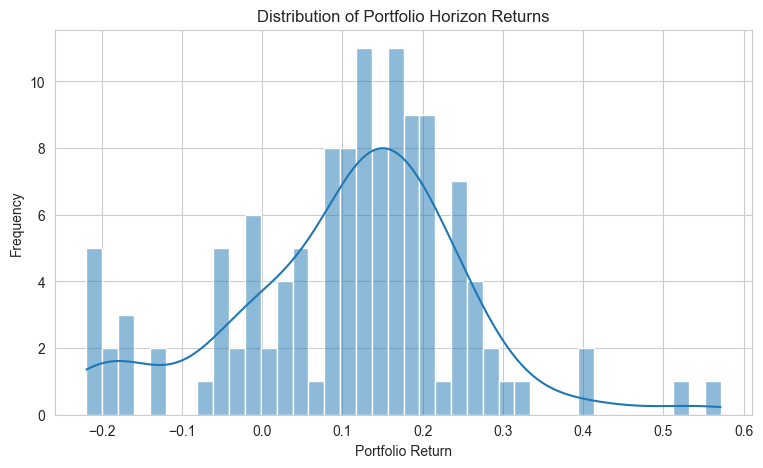

In [62]:
plt.figure(figsize=(9, 5))
sns.histplot(portfolio_returns, bins=40, kde=True)
plt.title("Distribution of Portfolio Horizon Returns")
plt.xlabel("Portfolio Return")
plt.ylabel("Frequency")
plt.show()

## Compute historical VaR and CVaR

In [63]:
def var_cvar(returns, alpha):
    returns = np.asarray(returns)
    sorted_returns = np.sort(returns)

    idx = int(np.floor((1 - alpha) * len(sorted_returns)))
    idx = max(idx, 1)

    var_return = sorted_returns[idx - 1]
    cvar_return = sorted_returns[:idx].mean()

    VaR = -var_return
    CVaR = -cvar_return

    return VaR, CVaR

In [64]:
VaR, CVaR = var_cvar(portfolio_returns.values, alpha)

VaR_dollars = VaR * initial_capital
CVaR_dollars = CVaR * initial_capital

print(f"VaR ({alpha:.0%})  = {VaR:.4%}  = ${VaR_dollars:,.2f}")
print(f"CVaR ({alpha:.0%}) = {CVaR:.4%} = ${CVaR_dollars:,.2f}")

VaR (95%)  = 19.7988%  = $197,987.98
CVaR (95%) = 20.5602% = $205,601.54


## Plot VaR and CVaR on the distribution

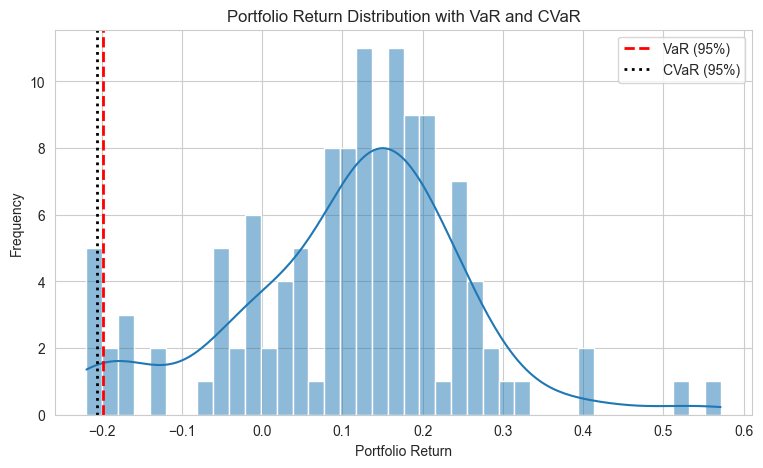

In [65]:
plt.figure(figsize=(9, 5))
sns.histplot(portfolio_returns, bins=40, kde=True)
plt.axvline(-VaR, color="red", linestyle="--", linewidth=2, label=f"VaR ({alpha:.0%})")
plt.axvline(-CVaR, color="black", linestyle=":", linewidth=2, label=f"CVaR ({alpha:.0%})")
plt.title("Portfolio Return Distribution with VaR and CVaR")
plt.xlabel("Portfolio Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Plot empirical CDF

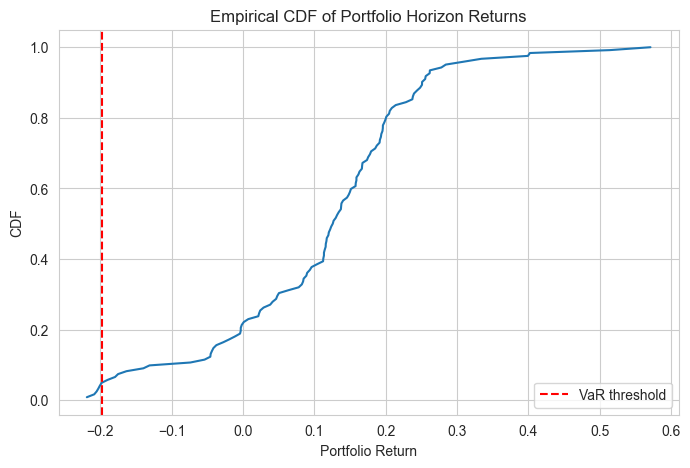

In [66]:
sorted_returns = np.sort(portfolio_returns.values)
ecdf = np.arange(1, len(sorted_returns) + 1) / len(sorted_returns)

plt.figure(figsize=(8, 5))
plt.plot(sorted_returns, ecdf)
plt.axvline(-VaR, color="red", linestyle="--", label="VaR threshold")
plt.title("Empirical CDF of Portfolio Horizon Returns")
plt.xlabel("Portfolio Return")
plt.ylabel("CDF")
plt.legend()
plt.show()

## Bootstrap simulation

In [85]:
n_sim = 10000
simulated_returns = np.random.choice(portfolio_returns.values, size=n_sim, replace=True)

VaR_sim, CVaR_sim = var_cvar(simulated_returns, alpha)

comparison = pd.DataFrame({
    "Method": ["Historical", "Bootstrap Simulation"],
    "VaR": [VaR, VaR_sim],
    "CVaR": [CVaR, CVaR_sim],
    "VaR ($)": [VaR * initial_capital, VaR_sim * initial_capital],
    "CVaR ($)": [CVaR * initial_capital, CVaR_sim * initial_capital],
})
display(comparison)

,Method,VaR,CVaR,VaR ($),CVaR ($)
0,Historical,0.197988,0.205602,197987.975616,205601.541311
1,Bootstrap Simulation,0.189650,0.205138,189650.062052,205137.572114


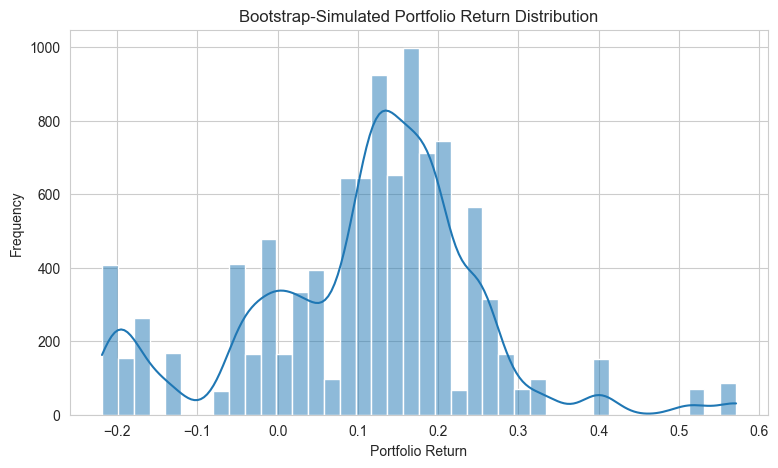

In [86]:
plt.figure(figsize=(9, 5))
sns.histplot(simulated_returns, bins=40, kde=True)
plt.title("Bootstrap-Simulated Portfolio Return Distribution")
plt.xlabel("Portfolio Return")
plt.ylabel("Frequency")
plt.show()

## Should Returns Be Annualized?

For this project, VaR and CVaR should be computed directly from the empirical distribution of realized $\tau$-horizon returns.

Annualization is not necessary because the objective is to measure risk over the chosen horizon itself. For example, if $\tau$ corresponds to one year, the most meaningful risk measure is the one-year loss distribution, not an annualized transformation of it.

Therefore, the most interpretable outputs are the horizon return VaR/CVaR and their corresponding dollar losses.

## Sector-based stress test

In [87]:
sector_shocks = {
    "Technology": -0.10,
    "Financial Services": -0.05,
    "Energy": 0.05,
    "Healthcare": 0.00,
    "Industrials": -0.02,
    "Real Estate": -0.02,
    "Consumer Cyclical": -0.03,
    "Consumer Defensive": 0.00,
    "Communication Services": -0.04,
    "Basic Materials": 0.00,
    "Utilities": 0.00,
}

In [88]:
def compute_fund_shocks(sectors_matrix, sector_shocks):
    shock_series = pd.Series(sector_shocks)

    common = sectors_matrix.columns.intersection(shock_series.index)
    exposure = sectors_matrix[common]
    shocks = shock_series[common]

    return exposure @ shocks

In [89]:
fund_shocks = compute_fund_shocks(sectors_d, sector_shocks)

print("Implied fund shocks:")
display(fund_shocks)

Implied fund shocks:


fund
B00496   -0.040405
B00698   -0.037843
B01060   -0.029222
B01061   -0.033066
B01637   -0.029543
B01855   -0.018433
B02943   -0.028061
B03459   -0.041622
B03731   -0.044277
B03784   -0.042046
dtype: float64

## Compute stressed VaR and CVaR

In [90]:
stressed_fund_returns = fund_returns.copy()

for fund in stressed_fund_returns.columns:
    stressed_fund_returns[fund] = stressed_fund_returns[fund] + fund_shocks[fund]

In [91]:
stressed_portfolio_returns = stressed_fund_returns @ weights

In [92]:
VaR_stress, CVaR_stress = var_cvar(stressed_portfolio_returns.values, alpha)

VaR_stress_dollars = VaR_stress * initial_capital
CVaR_stress_dollars = CVaR_stress * initial_capital

print(f"Stress VaR ({alpha:.0%})  = {VaR_stress:.4%}  = ${VaR_stress_dollars:,.2f}")
print(f"Stress CVaR ({alpha:.0%}) = {CVaR_stress:.4%} = ${CVaR_stress_dollars:,.2f}")

Stress VaR (95%)  = 23.2440%  = $232,439.78
Stress CVaR (95%) = 24.0053% = $240,053.34


## Base vs stressed portfolio risk

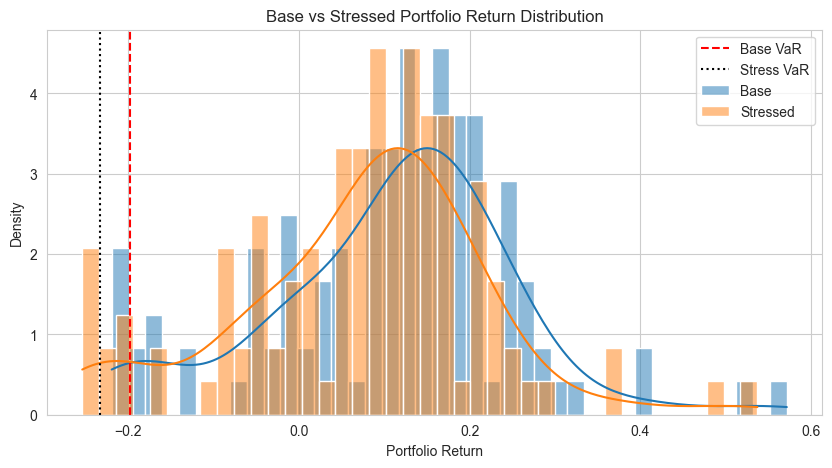

In [93]:
plt.figure(figsize=(10, 5))
sns.histplot(portfolio_returns, bins=40, kde=True, stat="density", alpha=0.5, label="Base")
sns.histplot(stressed_portfolio_returns, bins=40, kde=True, stat="density", alpha=0.5, label="Stressed")

plt.axvline(-VaR, color="red", linestyle="--", label="Base VaR")
plt.axvline(-VaR_stress, color="black", linestyle=":", label="Stress VaR")

plt.title("Base vs Stressed Portfolio Return Distribution")
plt.xlabel("Portfolio Return")
plt.ylabel("Density")
plt.legend()
plt.show()

## Summary table

In [94]:
summary = pd.DataFrame({
    "Metric": ["VaR", "CVaR"],
    "Base Return": [VaR, CVaR],
    "Base Dollars": [VaR_dollars, CVaR_dollars],
    "Stress Return": [VaR_stress, CVaR_stress],
    "Stress Dollars": [VaR_stress_dollars, CVaR_stress_dollars]
})

display(summary)

,Metric,Base Return,Base Dollars,Stress Return,Stress Dollars
0,VaR,0.197988,197987.975616,0.232440,232439.775616
1,CVaR,0.205602,205601.541311,0.240053,240053.341311


## Conclusion

This notebook constructed rolling $\tau$-horizon returns for a selected set of mutual funds and used these returns to estimate portfolio VaR and CVaR under an equal-weight allocation.

The results show how historical tail risk can be quantified directly from the empirical return distribution and how sector-based stress scenarios can materially alter the portfolio's downside risk profile.

The stress test is more realistic than arbitrary fund shocks because sector shocks are translated into fund-level impacts using each fund's sector exposure weights.

Overall, the notebook provides a practical framework for risk assessment across different investment horizons, rolling steps, and portfolio sizes.